# 04. 문제 유형별 출력층 설계

딥러닝 모델의 마지막 층은 문제 유형에 따라 달라진다.
회귀는 연속값을 예측하므로 출력 뉴런 수가 예측할 숫자 개수와 같고, 보통 별도의 활성화 없이 값을 그대로 낸다.
이진 분류는 한 클래스에 속할 확률을 예측하므로 출력 뉴런 1개를 사용하고, 다중 분류는 클래스 수만큼 logits를 출력한다.

출력층 설계는 손실함수 선택과 항상 함께 봐야 한다.
- 회귀: `MSELoss`나 `L1Loss`
- 이진 분류: `BCELoss` 또는 `BCEWithLogitsLoss`
- 다중 분류: `CrossEntropyLoss`

특히 PyTorch의 `BCEWithLogitsLoss`는 sigmoid와 BCE를 안정적으로 결합하고,
`CrossEntropyLoss`는 softmax 전의 logits를 입력받는다.

학생들이 자주 헷갈리는 부분은 "모델 출력에 sigmoid/softmax를 먼저 적용해야 하는가"이다. PyTorch에서는 손실함수가 내부에서 처리하는 경우가 많으므로, 출력층과 손실함수의 짝을 정확히 맞추는 것이 중요하다.


# 출력층 설계 (Output layer)

**회귀 vs 분류 출력층 비교표**

| 항목           | **회귀 (Regression)**            | **이진 분류 (Binary Classification)**        | **다중 분류 (Multi-class Classification)** |
| ------------ | ------------------------------ | ---------------------------------------- | -------------------------------------- |
| **출력층 뉴런 수** | 1개                             | 1개                                       | 클래스 수만큼 (예: 3개 클래스 → 3개 뉴런)            |
| **활성화 함수**   | 없음 (`Identity` = 항등함수)         | `Sigmoid`                                | 없음 (출력은 로짓값, softmax는 loss 내부 처리)      |
| **손실 함수**    | `MSELoss`, `L1Loss` 등          | `BCELoss`, `BCEWithLogitsLoss`           | `CrossEntropyLoss` (Softmax 포함)        |
| **정답 레이블**   | 실수 (float32), shape = `(n, 1)` | 0 또는 1 (float or long), shape = `(n, 1)` | 정수 (long), shape = `(n,)`              |
| **예측 방식**    | 그대로 출력 사용 (`ŷ`)                | `ŷ >= 0.5` → 1, else 0                   | `argmax(output, dim=1)`                |

<br/>

> 회귀는 **출력값에 제한이 없으므로** 아무 활성화도 적용하지 않음
>
> 이진 분류는 **확률**을 출력해야 하므로 sigmoid를 씌움. `BCEWithLogitsLoss` 사용하는 경우에는 **출력층에서는 sigmoid를 쓰지 않음**
>
> 다중 분류는 `CrossEntropyLoss`가 내부적으로 `Softmax` + `Log`를 처리하므로 **출력층에서는 softmax를 쓰지 않음**


## 회귀 출력층
항등함수란? $f(x) = x$와 같이 입력이 곧 출력이 함수를 가리킨다.
torch모델에서는 출력층 다음에 아무 활성화 함수를 사용하지 않는다.

#### 출력층 실습 라이브러리 불러오기

회귀, 이진 분류, 다중 분류 실습에 필요한 PyTorch와 sklearn 도구를 준비한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# F : 활성화함수
import torch.nn.functional as F

# optime : Optimizer
import torch.optim as optim
from torch.nn import CrossEntropyLoss


#### 회귀용 합성 데이터 생성

회귀 문제는 출력층이 연속값 1개를 예측하도록 데이터를 구성한다.


In [3]:
# 가중치, 편향이 정해진 합성 회귀데이터 생성
X = torch.randn(100, 2)

W = torch.tensor([[3., 2.]])
b = torch.tensor([5.])

noise = torch.randn(100, 1) * 2

y = X @ W.T + b + noise


#### 회귀 모델 구조 정의

회귀 모델의 마지막 출력층은 활성화 함수 없이 실수값 1개를 반환한다.


In [5]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, 10)
        self.relu = nn.ReLU() # 은닉층의 활성화함수
        # 출력층(입력10, 출력1개)
        # 회귀모델은 활성화함수 X -> 1개의 출력값이 예측값 자체임
        self.output = nn.Linear(10, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

print(X.size(1)) #2
# 딥러닝 모델생성
model = RegressionNet(input_dim = X.size(1))

# 생성된 모델에 예측결과와 실제값의 오차 측정 == 손실함수
# MSELoss : 예측값과 실제값의 평균제곱오차 -> 예측값과 실제값을 비교해 손실값을 만듦(최적화 시 사용)
criterion = nn.MSELoss()

# 오차를 줄이는 방향으로 W, b를 최적화함
# 이때 위의 loss값 사용
optimizer = optim.Adam(model.parameters(), lr=0.01)


2


#### 회귀 모델 학습 루프

MSELoss와 optimizer.step 흐름으로 연속값 예측 오차를 줄인다.


In [6]:
# 회귀 모델의 학습 루프를 3000번 반복해 MSELoss값을 줄임
# -> 예측 정확도를 증가시키기

# epoch : 1회 전체 학습 단위 ->[ 전체 학습데이터로 순전파 -> 손실함수 -> 최적화 ]
for epoch in range(3000):

    # 모델을 학습모드로 전환
    model.train()

    # 이전 최적화 진행시 계산한 기울기를 지우기
    # -> 이전 학습 기울기가 누적되지 않은 상태로 새로 학습
    optimizer.zero_grad()

    # 순전파(forward()) : X에 대한 예측 결과 반환
    pred = model(X)

    # loss 계산(nn.MSELoss() 호출)
    loss = criterion(pred, y)

    # 오차 역전파(backward()) : 오차를 이용해 돌아가서( 고칠부분 찾는다?)
    # loss를 줄이기 위해서는 각 뉴런의 W, b를 수정해야 해서, 모델 학습 방향을 반대로 돌림
    # W,b를 얼마나 바꿔야하는지 기울기 계산(미분)이 진행됨 -> 이 단계에서는 아직 W,b가 업데이트되지 않음(방향만 바꿈)
    loss.backward()

    # loss에서 계산된 기울기와 lr(learning rate)에 맞춰 W,b를 수정
    optimizer.step()

    if(epoch + 1) % 100 == 0:
        print(f'Epoch {epoch +1} : Loss {loss.item()}')


# loss가 학습을 반복하면서 줄어들고 있는것을 확인
# ==optimizer가 올바른 방향으로 수정하고있다는뜻

# loss가 거의 줄지않는상태
# == lr, 모델구조, 입력과 정답의 shape/dtype 확인



Epoch 100 : Loss 4.450255393981934
Epoch 200 : Loss 4.079814910888672
Epoch 300 : Loss 4.043015480041504
Epoch 400 : Loss 4.030050754547119
Epoch 500 : Loss 4.017904281616211
Epoch 600 : Loss 4.004367351531982
Epoch 700 : Loss 3.9914472103118896
Epoch 800 : Loss 3.9754879474639893
Epoch 900 : Loss 3.9583373069763184
Epoch 1000 : Loss 3.9452521800994873
Epoch 1100 : Loss 3.9352941513061523
Epoch 1200 : Loss 3.918516159057617
Epoch 1300 : Loss 3.9120230674743652
Epoch 1400 : Loss 3.909222364425659
Epoch 1500 : Loss 3.9060661792755127
Epoch 1600 : Loss 3.9043009281158447
Epoch 1700 : Loss 3.9036405086517334
Epoch 1800 : Loss 3.903088331222534
Epoch 1900 : Loss 3.902608871459961
Epoch 2000 : Loss 3.902242660522461
Epoch 2100 : Loss 3.9018478393554688
Epoch 2200 : Loss 3.9014954566955566
Epoch 2300 : Loss 3.9012346267700195
Epoch 2400 : Loss 3.9010376930236816
Epoch 2500 : Loss 3.9008235931396484
Epoch 2600 : Loss 3.9005672931671143
Epoch 2700 : Loss 3.9005026817321777
Epoch 2800 : Loss 3.9

#### 회귀 예측 결과 시각화

실제값과 예측값이 기준선 가까이에 모일수록 회귀 모델이 잘 맞은 것이다.


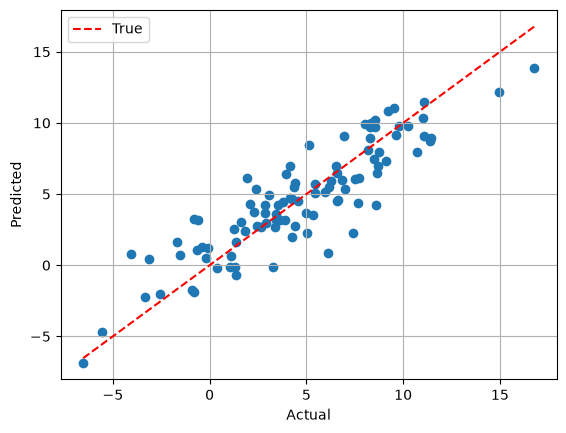

In [7]:
with torch.no_grad():

    model.eval()
    pred = model(X)

plt.scatter(y.numpy(), pred.numpy())

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='True')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid()
plt.show()


#### 모델 파라미터 shape 확인

named_parameters로 계층별 weight와 bias shape를 확인해 출력층 구조를 해석한다.


In [8]:
for name, param in model.named_parameters():

    print(f'{name}: {param.shape}')


hidden.weight: torch.Size([10, 2])
hidden.bias: torch.Size([10])
output.weight: torch.Size([1, 10])
output.bias: torch.Size([1])


### 캘리포니아 집값 예측

#### California Housing 데이터 전처리

딥러닝 회귀에서는 입력과 타깃 스케일링이 학습 안정성에 중요하다.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()

y_scaler = StandardScaler()

X = X_scaler.fit_transform(X)

# 회귀 target도 스케일링 진행
# 스케일링된 X에 비해 y값이 너무 커서 loss가 불안정해지기 때문 -> 이를 대비하기 위한 스케일링
y = y_scaler.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


(20640, 8) (20640,)


#### California 회귀 모델 직접 정의

여러 Linear와 ReLU 계층을 직접 선언해 회귀 네트워크를 구성한다.


In [12]:
class CaliforniaHousingNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.hidden1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()

        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x


#### nn.Sequential 회귀 모델

- nn.Sequential 회귀 모델은 여러 신경망 계층을 실행할 순서대로 나열해서 만든 회귀 모델
- 단순히 앞에서 뒤로 흐르는 모델을 간결하게 작성할 때 사용한다.


In [13]:
class CaliforniaHousingNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # 모듈 객체를 순서대로 묶고 실행(forward 구현체)
        # nn.Sequential() : 순서대로 이어지는 단순 신경망 구현시 사용
        self.net = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):

        return self.net(x)

model = CaliforniaHousingNet(input_dim=X.shape[1])
# 손실함수를 이용한 오차 계산용 함수
criterion = nn.MSELoss()
# 최적화 알고리즘, 오차를 개선하는 방향으로 모델 파라미터(W,b)를 업데이트
optimizer = optim.Adam(model.parameters(), lr=0.01)


#### torchinfo로 모델 구조 확인

summary는 각 계층의 출력 shape와 파라미터 수를 확인하는 데 유용하다.


In [14]:
from torchinfo import summary

summary(model, input_data=X_train)


Layer (type:depth-idx)                   Output Shape              Param #
CaliforniaHousingNet                     [16512, 1]                --
├─Sequential: 1-1                        [16512, 1]                --
│    └─Linear: 2-1                       [16512, 64]               576
│    └─ReLU: 2-2                         [16512, 64]               --
│    └─Linear: 2-3                       [16512, 32]               2,080
│    └─ReLU: 2-4                         [16512, 32]               --
│    └─Linear: 2-5                       [16512, 1]                33
Total params: 2,689
Trainable params: 2,689
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 44.40
Input size (MB): 0.53
Forward/backward pass size (MB): 12.81
Params size (MB): 0.01
Estimated Total Size (MB): 13.35

#### California 회귀 모델 학습

train 모드에서 forward, loss, backward, step을 반복해 손실을 낮춘다.


In [15]:
model.train() # 모델을 학습모드로 변경

for epoch in range(1000): # 모든 데이터의 학습과정을 1000번 반복

    optimizer.zero_grad() # 이전학습 기울기 리셋

    pred = model(X_train) # 예측

    loss = criterion(pred, y_train)  # loss 계산

    loss.backward() # 오차 역전파(기울기 계산)

    optimizer.step() # 위에서 계산한 기울기 + lr을 이용해서 W,b를 업데이트(최적화)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 100: Loss: 0.22873389720916748
Epoch 200: Loss: 0.1971239149570465
Epoch 300: Loss: 0.18336018919944763
Epoch 400: Loss: 0.17750445008277893
Epoch 500: Loss: 0.17164252698421478
Epoch 600: Loss: 0.17467756569385529
Epoch 700: Loss: 0.17149710655212402
Epoch 800: Loss: 0.16141550242900848
Epoch 900: Loss: 0.15862341225147247
Epoch 1000: Loss: 0.15801501274108887


#### 회귀 모델 평가 지표 계산

스케일링한 타깃을 원래 단위로 복원한 뒤 RMSE, MSE, MAE, R2를 계산한다.


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

model.eval()

with torch.no_grad():
    pred = model(X_test)

y_test_inv = y_scaler.inverse_transform(y_test)

pred_inv = y_scaler.inverse_transform(pred)

print(f'RMSE: {root_mean_squared_error(y_test_inv, pred_inv)}')
print(f'MSE: {mean_squared_error(y_test_inv, pred_inv)}')
print(f'MAE: {mean_absolute_error(y_test_inv, pred_inv)}')
print(f'R^2: {r2_score(y_test_inv, pred_inv)}')


RMSE: 0.5088011766640462
MSE: 0.25887863737471795
MAE: 0.3344468479901116
R^2: 0.802444398558214


#### 회귀 예측 산점도

산점도와 기준선을 통해 실제값 대비 예측값의 분포를 시각적으로 확인한다.


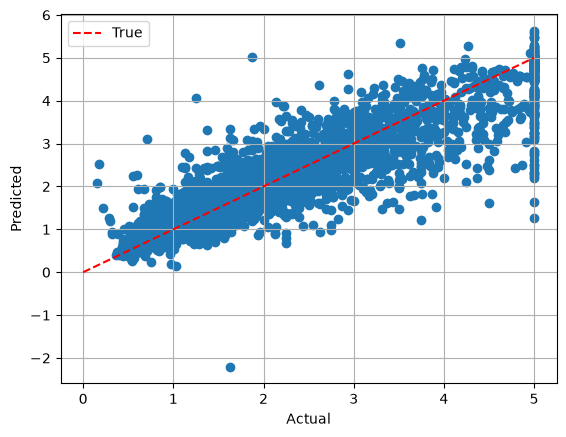

In [17]:
plt.scatter(y_test_inv, pred_inv)

plt.plot([0, y_test_inv.max()], [0, y_test_inv.max()], 'r--', label='True')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid()
plt.show()


# 기준선에 점이 가까움 = 오차가 적음 = 예측 잘함
# 특정구간에서 점이 벌어짐 = 해당범위에 대한 예측이 편향됨을 의심


## 분류 출력층

### 이진분류
- Sigmoid 활성화 함수 사용
- 은닉층/출력층을 거쳐온 결과값(z)을 확률값(p)으로 변환
- 설정한 임계치 이상이면 양성으로 예측

#### 시그모이드와 임계값

이진 분류는 sigmoid 확률을 threshold 기준으로 0/1 클래스로 바꾼다.


In [19]:
torch.manual_seed(42)

# 생성된 난수 == 선형 방정식의 결과취급 == z == logits (선형방정식의 결과)
z = torch.randn(100) * 10

# sigmoid 활성화 함수를 이용해 logits값을 0-1 사이 확률값으로 변경
p = F.sigmoid(z)

threshold = 0.3 # 임계값

# 임계값 이상 == 1, 미만 0으로 이진 분류
pred = (p >= threshold).int()

pd.DataFrame({
    'z': z.numpy(),
    'p': p.numpy(),
    'pred': pred.numpy(),
})


,z,p,pred
0,19.269154,1.000000e+00,1
1,14.872841,9.999996e-01,1
2,9.007172,9.998775e-01,1
3,-21.055210,7.175273e-10,0
4,6.784184,9.988697e-01,1
...,...,...,...
95,-3.036038,4.582411e-02,0
96,-9.864387,5.199107e-05,0
97,1.232991,7.743417e-01,1
98,3.498678,9.706501e-01,1


### 다중분류
- Softmax 활성화함수 사용
- 각 클래스별 계산값을 입력으로 받아, 각 클래스별 확률값으로 변환(모든 클래스의 확률값 합 1)
- 벡터를 입력받아 벡터로 반환

#### 단일 샘플 Softmax

Softmax는 한 샘플의 클래스 점수를 합이 1인 확률로 바꾼다.


In [20]:
z = torch.tensor([2., 1.5, 4, 0.7])
print(z)

output = F.softmax(z, dim=0)
print(output)# 확률 합계가 1이 되는지 확인


tensor([2.0000, 1.5000, 4.0000, 0.7000])
tensor([0.1079, 0.0654, 0.7973, 0.0294])


#### 여러 샘플 Softmax

dim=1은 각 샘플 행 안에서 클래스 확률 합이 1이 되도록 계산한다.


In [21]:
z = torch.tensor([[2., 1.5, 4, 0.7],
                  [3., 1.1, 10.7, 1.9]])
print(z)

output = F.softmax(z, dim=1) # 각 행마다 확률 계산(행의 확률합 1)
print(output)

pred = output.argmax(dim=1) # 각 행에서 최대값의 인덱스를 반환
print(pred)

print(output.sum(dim=1))


tensor([[ 2.0000,  1.5000,  4.0000,  0.7000],
        [ 3.0000,  1.1000, 10.7000,  1.9000]])
tensor([[1.0790e-01, 6.5443e-02, 7.9726e-01, 2.9405e-02],
        [4.5252e-04, 6.7683e-05, 9.9933e-01, 1.5063e-04]])
tensor([2, 2])
tensor([1.0000, 1.0000])


#### 다중 클래스에서 Sigmoid 사용 비교

Sigmoid는 클래스별 독립 확률이라 다중 클래스 단일 정답 문제에는 Softmax와 다르게 해석된다.


In [22]:
z = torch.tensor([[2., 1.5, 4, 0.7],
                  [3., 1.1, 10.7, 1.9]])
print(z)

p = F.sigmoid(z)
print(p)

pred = p.argmax(dim=1)
print(pred)

# SOFTMAX는 각 행을 하난의 단위로 묶어서 함수로 전달
# -> 예측 합계 합이 항상 1

# 각 logit을 독립적으로 sigmoid 함수에 전달하여 값을 변환
# -> 예측합계가 1이 되지 않음(될수도 있긴함)
# 크기순으로 sigmoid 결과값이 배정됨 -> 다중분류 x


tensor([[ 2.0000,  1.5000,  4.0000,  0.7000],
        [ 3.0000,  1.1000, 10.7000,  1.9000]])
tensor([[0.8808, 0.8176, 0.9820, 0.6682],
        [0.9526, 0.7503, 1.0000, 0.8699]])
tensor([2, 2])


### 출력층과 손실함수 연계

**이진분류**
- 출력층 sigmoid + 손실함수 BCELoss  <- 모델이 직접 sigmoid를 적용해 확률을 출력함
- 출력층 x + 손실함수 BCEWithLogitsLoss <- 모델은 sigmoid를 적용하지 않고 logit 원본을 출력하고, 손실 함수가 sigmoid를 적용한다.

**다중분류**
- 출력층 x + 손실함수 CrossEntropyLoss

#### 이진분류: 출력층 sigmoid + 손실함수 BCELoss

#### 이진 분류 데이터 생성

make_classification으로 이진 분류용 특성과 라벨을 만들고 Tensor로 변환한다.


In [23]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=10,
    n_informative=5,

    n_classes=2,
    random_state=42
)
print(X.shape, y.shape)

X = torch.tensor(X, dtype=torch.float32)

y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print(X.shape, y.shape)


(100, 10) (100,)
torch.Size([100, 10]) torch.Size([100, 1])


#### Sigmoid 출력 이진 분류 모델

출력층에 Sigmoid를 붙이면 BCELoss에 넣을 확률값이 나온다.


In [26]:
class BinaryClassificationNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),

            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = BinaryClassificationNet(input_dim=X.size(1))

# 손실함수 - BCEWithLogitsLoss
# logits를이용해서 오차 계산하는 함수
# 내부에 sigmoid와 BCE를 함께 처리해서 수치적으로 더 안정적인 결과를 반환

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)


#### BCELoss 기반 이진 분류 학습

확률값과 0/1 정답을 비교해 이진 분류 모델을 학습한다.


In [27]:
epochs = 100

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(X) # 모델에 x 전달해서 결과예측(0.5 기준 0/1 이진분류)

    loss = criterion(pred, y) # 오차측정(MSE, 100개 샘플오차제곱평균)

    loss.backward()# 오차역전파(오차감소 위한 기울기 계산)
    optimizer.step() # 최적화

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 10: Loss: 0.37423980236053467
Epoch 20: Loss: 0.1877603381872177
Epoch 30: Loss: 0.10564418882131577
Epoch 40: Loss: 0.06148992478847504
Epoch 50: Loss: 0.03567532077431679
Epoch 60: Loss: 0.021716639399528503
Epoch 70: Loss: 0.014316268265247345
Epoch 80: Loss: 0.010105813853442669
Epoch 90: Loss: 0.007577889133244753
Epoch 100: Loss: 0.005957667715847492


#### 출력층 x + 손실함수 BCEWithLogitsLoss

#### Logits 출력 이진 분류 모델

BCEWithLogitsLoss를 쓸 때는 출력층에 Sigmoid를 붙이지 않는다.


#### BCEWithLogitsLoss 기반 학습

logits를 그대로 손실함수에 넣으면 내부에서 sigmoid와 BCE가 안정적으로 계산된다.


In [29]:
epochs = 100

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 10: Loss: 0.0013659610413014889
Epoch 20: Loss: 0.0012516910210251808
Epoch 30: Loss: 0.001151805859990418
Epoch 40: Loss: 0.0010636833030730486
Epoch 50: Loss: 0.0009847991168498993
Epoch 60: Loss: 0.0009139019530266523
Epoch 70: Loss: 0.0008500311523675919
Epoch 80: Loss: 0.0007928124978207052
Epoch 90: Loss: 0.0007413920247927308
Epoch 100: Loss: 0.000694947550073266


#### 유방암 예측

https://www.notion.so/shqkel/Datasets-1c39cb46e5e2818f8ae1c282ee5fadf8?p=1f39cb46e5e281c4876be717b656272b&pm=s

#### Breast Cancer 데이터 전처리

실제 이진 분류 데이터에서 스케일링, 분할, Tensor 변환을 수행한다.


In [30]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.dtype)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# unsqueeze(-1)의 목적
# BCE손실함수에 맞도록  y의  shape을 맞춤
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(X_train.dtype)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(569, 30) (569,)
float64
torch.float32
torch.Size([455, 30]) torch.Size([455, 1])
torch.Size([114, 30]) torch.Size([114, 1])


#### Breast Cancer 모델 정의

BCEWithLogitsLoss에 맞춰 마지막 계층은 logits 1개만 반환한다.


In [33]:
class BreastCancerNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()# 부모부분 생성 -> 파라미터 추적 on

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),# 은닉 1층
            nn.ReLU(), # 은닉 1층 결과의 활성화
            nn.Linear(32,16), # 은닉 2
            nn.ReLU(), # 은닉 2 활성화
            nn.Linear(16,1) # 출력
            # 활성화 x -> logits 형태로 변환
        )

    def forward(self, x):
        return self.net(x)

# 모델 생성 (입력값 X_train.size(1) = X_train 열의 수)
model = BreastCancerNet(input_dim = X_train.size(1))

# 손실함수(sigmoid + BCE 포함)
criterion = nn.BCEWithLogitsLoss()

# 파라미터 최적화
optimizer = optim.Adam(model.parameters(), lr=0.01)


#### Breast Cancer 모델 학습

이진 분류 학습 루프에서도 핵심 순서는 zero_grad, forward, loss, backward, step이다.


In [34]:
model.train()

for epoch in range(300):

    optimizer.zero_grad()

    pred = model(X_train)

    loss = criterion(pred, y_train)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')


Epoch 10: Loss 0.14167508482933044
Epoch 20: Loss 0.06054294854402542
Epoch 30: Loss 0.03977476805448532
Epoch 40: Loss 0.02512260340154171
Epoch 50: Loss 0.01669752039015293
Epoch 60: Loss 0.011280950158834457
Epoch 70: Loss 0.007699714507907629
Epoch 80: Loss 0.005087593570351601
Epoch 90: Loss 0.003154108766466379
Epoch 100: Loss 0.0018556923605501652
Epoch 110: Loss 0.0010990818263962865
Epoch 120: Loss 0.0007095010951161385
Epoch 130: Loss 0.0005080048576928675
Epoch 140: Loss 0.00038965317071415484
Epoch 150: Loss 0.0003145596419926733
Epoch 160: Loss 0.0002619411388877779
Epoch 170: Loss 0.0002239586174255237
Epoch 180: Loss 0.0001947843556990847
Epoch 190: Loss 0.0001716924598440528
Epoch 200: Loss 0.00015292144962586462
Epoch 210: Loss 0.00013722195581067353
Epoch 220: Loss 0.00012402246647980064
Epoch 230: Loss 0.00011287954112049192
Epoch 240: Loss 0.00010333966201869771
Epoch 250: Loss 9.504309127805755e-05
Epoch 260: Loss 8.783052180660889e-05
Epoch 270: Loss 8.14707891549

#### 이진 분류 모델 평가

logits를 sigmoid 확률로 바꾼 뒤 0.5 기준으로 클래스를 결정한다.


In [35]:
from sklearn.metrics import accuracy_score

model.eval()

with torch.no_grad():

    logits = model(X_test) # 학습때 사용하지 않은 X_test 예측

    p = F.sigmoid(logits)

    pred = (p >= 0.5).int()

    print('정확도: ', accuracy_score(y_test, pred))


정확도:  0.956140350877193


#### 출력층 x + 손실함수 CrossEntropyLoss

#### 다중 분류 장난감 데이터와 모델

CrossEntropyLoss는 클래스별 logits와 정수 라벨을 입력으로 받는다.


In [38]:
torch.manual_seed(42)
X = torch.rand(4,5) # 4행 5열 = 4개의 데이터 feature 5개
print(X)
y=torch.tensor([0,2,1,0])

n_class = len(y.unique()) # 출력층 노드 수 =3

class MultiClassificationNet(nn.Module):
    def __init__(self, input_dim, n_class):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),# 은닉층
            nn.ReLU(), # 은닉층 활성화 함수
            nn.Linear(32,n_class) #  출력층(logits, 출력값 3개)
        )

    def forward(self, x):
        return self.net(x)


model = MultiClassificationNet(input_dim=X.size(1), n_class=n_class)

# 손실함수 -> 다중분류용 손실함수인 CrossEntropyLoss사용
# CrossEntropyLoss : 내부에 softmax, NLLLoss를 내부에서 처리함
# softmax에 전달할 데이터의 모습은 logit형태
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)



tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904],
        [0.6009, 0.2566, 0.7936, 0.9408, 0.1332],
        [0.9346, 0.5936, 0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739, 0.2666, 0.6274]])


#### 다중 분류 모델 학습

다중 분류에서는 softmax를 모델에 붙이지 않고 logits를 손실함수에 넣는다.


In [39]:
model.train()
for epoch in range(100):

    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')


Epoch 10: Loss 0.8434354066848755
Epoch 20: Loss 0.5997275710105896
Epoch 30: Loss 0.3533501625061035
Epoch 40: Loss 0.1756024956703186
Epoch 50: Loss 0.08264607191085815
Epoch 60: Loss 0.042740605771541595
Epoch 70: Loss 0.025621425360441208
Epoch 80: Loss 0.01753735914826393
Epoch 90: Loss 0.01314586866647005
Epoch 100: Loss 0.010451257228851318


#### 붓꽃데이터 예측

#### Iris 데이터 전처리

다중 분류 실습에서는 입력은 float Tensor, 정답은 long Tensor로 준비한다.


In [40]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


(150, 4) (150,)


#### Iris 다중 분류 학습과 평가

logits를 softmax 확률로 바꾸고 argmax로 최종 클래스를 선택한다.


In [41]:
class IrisNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = IrisNet(input_dim=X_train.size(1), output_dim=3)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(100):
    optimizer.zero_grad()

    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')

model.eval()
with torch.no_grad():
    logits = model(X_test)
    print('logits:', logits[:2])

    p = F.softmax(logits, dim=1)
    print('p:', p[:2])

    pred = p.argmax(dim=1)
    print('pred:', pred[:2])
    print('y_true:', y_test[:2])
    print('정확도: ', accuracy_score(y_test, pred))


Epoch 10: Loss 0.40250492095947266
Epoch 20: Loss 0.22785227000713348
Epoch 30: Loss 0.1302189975976944
Epoch 40: Loss 0.08055683970451355
Epoch 50: Loss 0.05833476036787033
Epoch 60: Loss 0.04788466915488243
Epoch 70: Loss 0.04222144931554794
Epoch 80: Loss 0.03856981173157692
Epoch 90: Loss 0.035948995500802994
Epoch 100: Loss 0.033862244337797165
logits: tensor([[ 6.8814, -2.3631, -9.2703],
        [-4.9914,  1.5230,  2.8149]])
p: tensor([[9.9990e-01, 9.6633e-05, 9.6685e-08],
        [3.1930e-04, 2.1547e-01, 7.8422e-01]])
pred: tensor([0, 2])
y_true: tensor([0, 2])
정확도:  0.9666666666666667
